<a href="https://colab.research.google.com/github/ligia-soares-ds/credit-card-fraud/blob/main/fraude_cartao_mvp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Detecção de Fraude em Cartões de Crédito

**Aluna:** Ligia Soares  
**Curso:** Pós-graduação — Ciência de Dados e Analytics  
**Instituição:** PUC-Rio  

---

## Descrição do problema

Fraudes em transações com cartão de crédito causam prejuízos bilionários para instituições financeiras e consumidores. Identificar automaticamente transações fraudulentas é um problema de **classificação binária supervisionada**, em que a variável-alvo indica se uma transação é fraude (`Class = 1`) ou legítima (`Class = 0`).

O principal desafio deste dataset é o **alto desbalanceamento entre as classes**: apenas 0,17% das transações são fraudulentas.

## Objetivo

Construir e avaliar modelos de Machine Learning capazes de detectar fraudes com alta taxa de acerto para a classe positiva (fraude), utilizando métricas adequadas para dados desbalanceados.

## Dataset

- **Nome:** Credit Card Fraud Detection
- **Fonte:** Kaggle — [acessar dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- **Transações totais:** 284.807
- **Fraudes:** 492 (0,17%)
- **Variáveis:** 30 features numéricas (V1–V28 anonimizadas via PCA) + `Time`, `Amount` e `Class`

In [30]:
# Bibliotecas de manipulação e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [10]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


## 1. Análise Exploratória dos Dados (EDA)

Nesta etapa, é realizada uma análise exploratória inicial com o objetivo de compreender a estrutura da base, verificar a presença de valores ausentes, identificar o comportamento da variável-alvo e observar características relevantes para a modelagem.

Como se trata de um problema de detecção de fraude, um dos principais pontos de atenção é o forte desbalanceamento entre as classes, já que a quantidade de transações fraudulentas representa uma parcela muito pequena do total.

### 1.1 Estrutura dos dados

A seguir, são analisados os tipos das variáveis e a existência de valores ausentes. Essa verificação é importante para identificar possíveis problemas de qualidade dos dados antes da modelagem.

In [12]:
import pandas as pd

df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

# Visualização inicial do dataset
display(df.head())

print("Dimensões do dataset:", df.shape)
print("\nNomes das colunas:")
print(df.columns.tolist())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Dimensões do dataset: (284807, 31)

Nomes das colunas:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [13]:
# Informações gerais da base
df.info()

# Valores ausentes
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

print("\nTotal de valores ausentes no dataset:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,0



Total de valores ausentes no dataset: 0


### 1.2 Distribuição da variável-alvo

A variável `Class` indica se a transação é legítima (`0`) ou fraudulenta (`1`). Como a base é altamente desbalanceada, essa análise é essencial para orientar a escolha das métricas de avaliação.

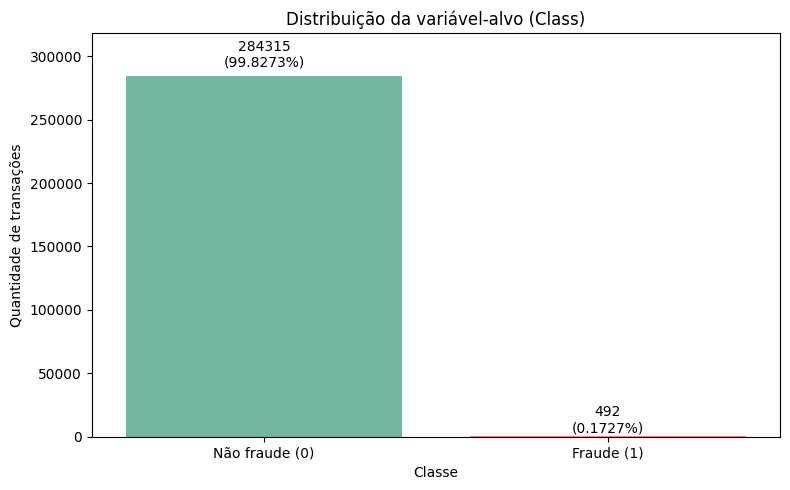

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem absoluta e percentual da variável-alvo
class_counts = df["Class"].value_counts()
class_percent = df["Class"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Quantidade": class_counts,
    "Percentual (%)": class_percent.round(4)
}).reset_index().rename(columns={"index": "Class"})

summary["Classe"] = summary["Class"].map({0: "Não fraude (0)", 1: "Fraude (1)"})

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=summary,
    x="Classe",
    y="Quantidade",
    hue="Classe",
    palette="Set2",
    dodge=False,
    legend=False
)

plt.title("Distribuição da variável-alvo (Class)")
plt.xlabel("Classe")
plt.ylabel("Quantidade de transações")

for i, row in summary.iterrows():
    offset = 5000 if row["Quantidade"] > 100000 else 500
    ax.text(
        i,
        row["Quantidade"] + offset,
        f'{int(row["Quantidade"])}\n({row["Percentual (%)"]:.4f}%)',
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, summary["Quantidade"].max() * 1.12)
plt.tight_layout()
plt.show()

### 1.3 Interpretação inicial

Observa-se que a base é extremamente desbalanceada, com predominância quase total de transações não fraudulentas. Isso torna a tarefa de classificação mais desafiadora, pois um modelo pode atingir alta acurácia mesmo sem identificar corretamente os casos de fraude.

Dessa forma, nas etapas posteriores, será necessário utilizar métricas mais adequadas ao problema, como **precision**, **recall**, **F1-score** e **ROC-AUC**.

### 1.4 Análise das variáveis `Amount` e `Time`

As variáveis `Amount` e `Time` merecem atenção especial, pois não foram anonimizadas por PCA. A variável `Amount` representa o valor da transação, enquanto `Time` indica os segundos decorridos desde a primeira transação registrada na base.

A análise dessas variáveis permite observar padrões iniciais, dispersão, possíveis outliers e diferenças de comportamento entre transações legítimas e fraudulentas.

In [21]:
# Estatísticas descritivas das variáveis numéricas
display(df[["Time", "Amount"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16


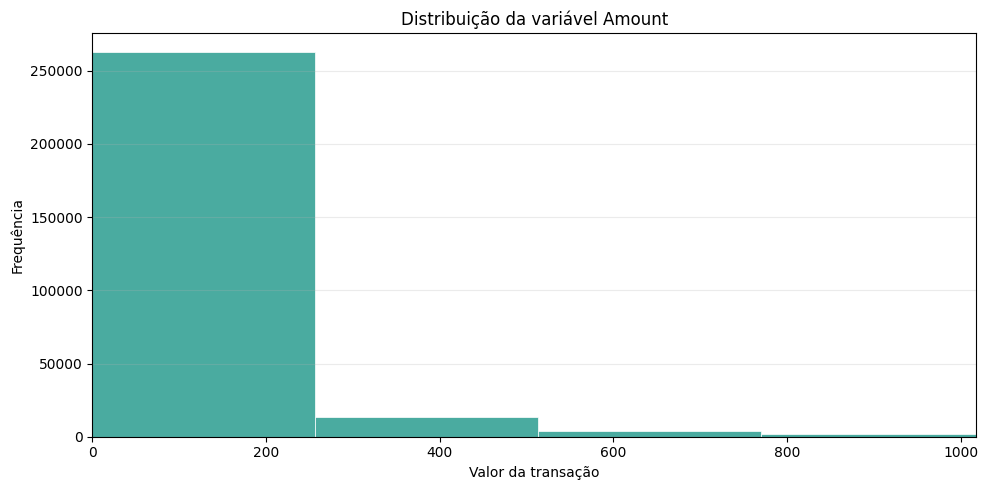

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(
    df["Amount"],
    bins=100,
    color="#2a9d8f",
    edgecolor="white",
    alpha=0.85
)

plt.title("Distribuição da variável Amount")
plt.xlabel("Valor da transação")
plt.ylabel("Frequência")
plt.xlim(0, df["Amount"].quantile(0.99))
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

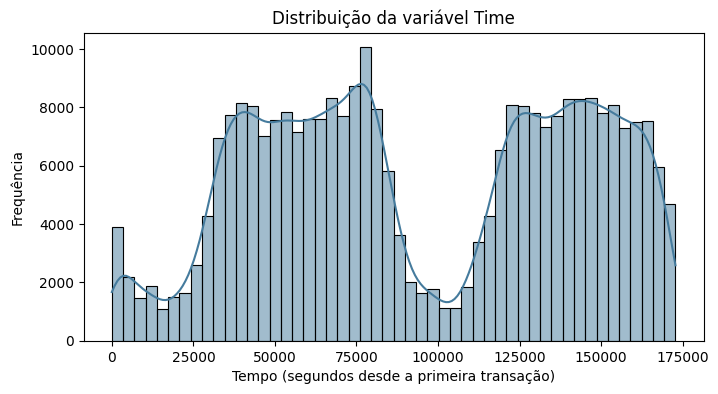

In [25]:
plt.figure(figsize=(8,4))
sns.histplot(df["Time"], bins=50, kde=True, color="#457b9d")
plt.title("Distribuição da variável Time")
plt.xlabel("Tempo (segundos desde a primeira transação)")
plt.ylabel("Frequência")
plt.show()

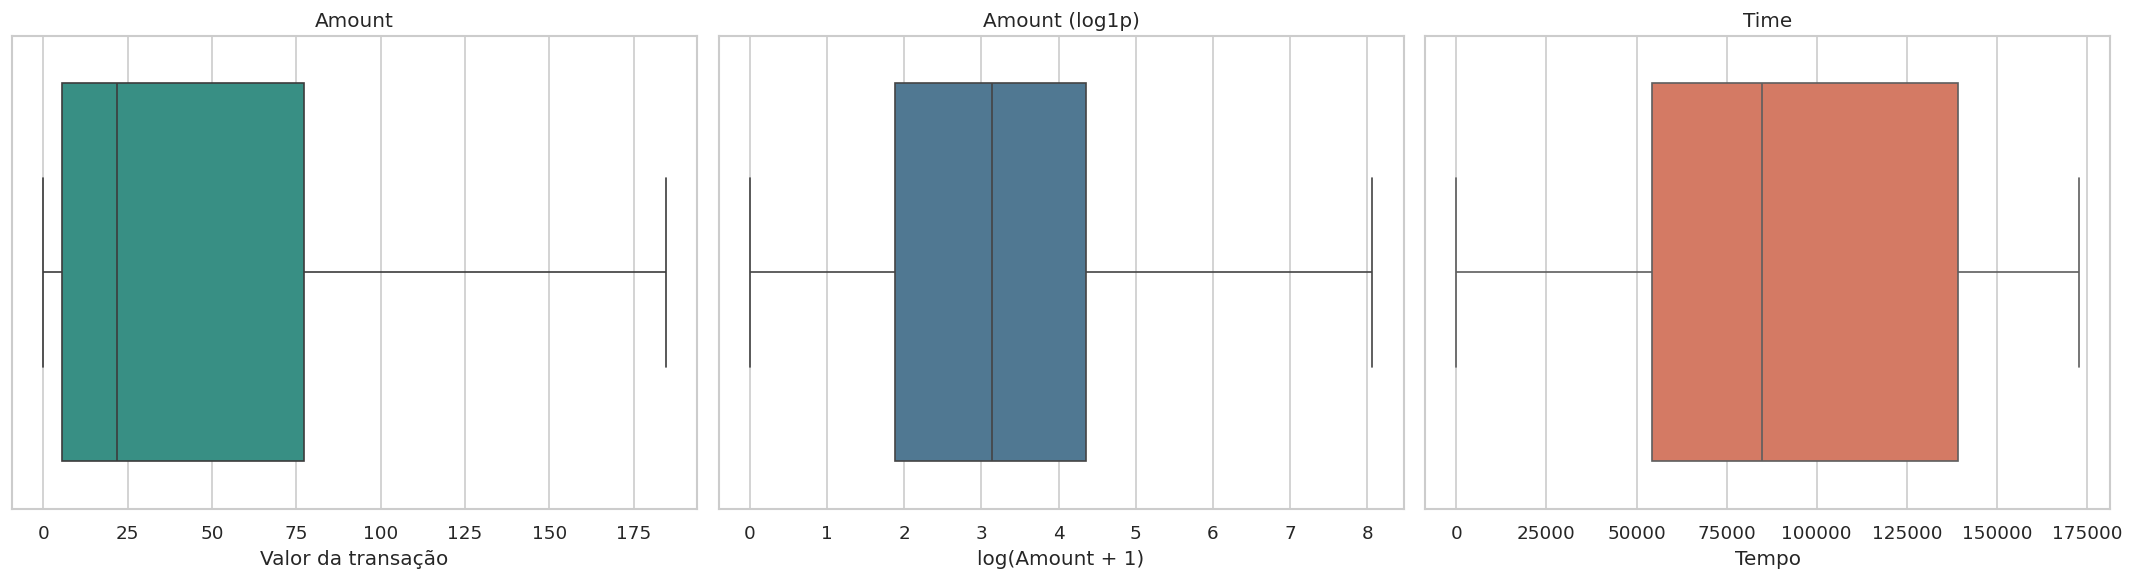

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=df["Amount"], ax=axes[0], color="#2a9d8f", showfliers=False)
axes[0].set_title("Amount")
axes[0].set_xlabel("Valor da transação")

sns.boxplot(x=np.log1p(df["Amount"]), ax=axes[1], color="#457b9d", showfliers=False)
axes[1].set_title("Amount (log1p)")
axes[1].set_xlabel("log(Amount + 1)")

sns.boxplot(x=df["Time"], ax=axes[2], color="#e76f51", showfliers=False)
axes[2].set_title("Time")
axes[2].set_xlabel("Tempo")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2893/3447246238.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Não fraude", "Fraude"])
/tmp/ipykernel_2893/3447246238.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Não fraude", "Fraude"])


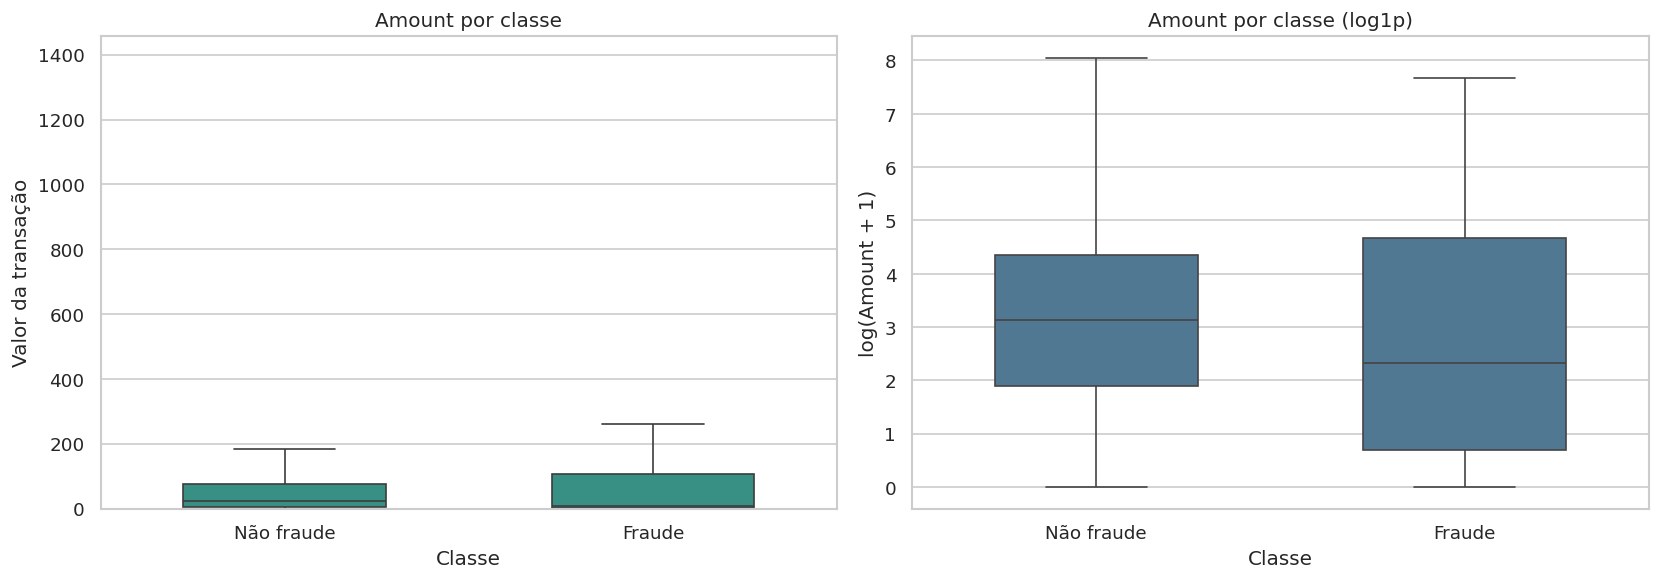

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    order=[0, 1],
    ax=axes[0],
    color="#2a9d8f",
    showfliers=False,
    width=0.55
)
axes[0].set_title("Amount por classe")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Valor da transação")
axes[0].set_xticklabels(["Não fraude", "Fraude"])
ax = axes[0]
ax.set_ylim(0, df["Amount"].quantile(0.995))

df2 = df.copy()
df2["Amount_log"] = np.log1p(df2["Amount"])

sns.boxplot(
    data=df2,
    x="Class",
    y="Amount_log",
    order=[0, 1],
    ax=axes[1],
    color="#457b9d",
    showfliers=False,
    width=0.55
)
axes[1].set_title("Amount por classe (log1p)")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("log(Amount + 1)")
axes[1].set_xticklabels(["Não fraude", "Fraude"])

plt.tight_layout()
plt.show()

### 1.5 Interpretação de `Amount` e `Time`

A variável `Amount` apresenta forte assimetria à direita, indicando a presença de muitas transações de baixo valor e poucas transações com valores elevados. Esse comportamento sugere a existência de outliers e reforça a necessidade de considerar escalonamento ou transformação dessa variável na etapa de preparação dos dados.

A variável `Time`, por sua vez, representa a ordem temporal relativa das transações na base. Sua distribuição ajuda a compreender como os registros se espalham ao longo do período observado, embora, isoladamente, não permita interpretação direta de calendário ou horário real.

A comparação entre classes permite investigar se transações fraudulentas tendem a apresentar padrões distintos em relação ao valor e ao instante em que ocorrem.

### 1.6 Análise de correlação

Nesta etapa, busca-se identificar relações lineares entre as variáveis numéricas e a variável-alvo `Class`. A matriz de correlação é útil para destacar quais atributos apresentam associação mais forte com a ocorrência de fraude.

Como parte das variáveis foi anonimizada por PCA, a interpretação semântica dos atributos `V1` a `V28` é limitada. Ainda assim, a correlação ajuda a identificar quais delas podem ser mais relevantes para a modelagem.

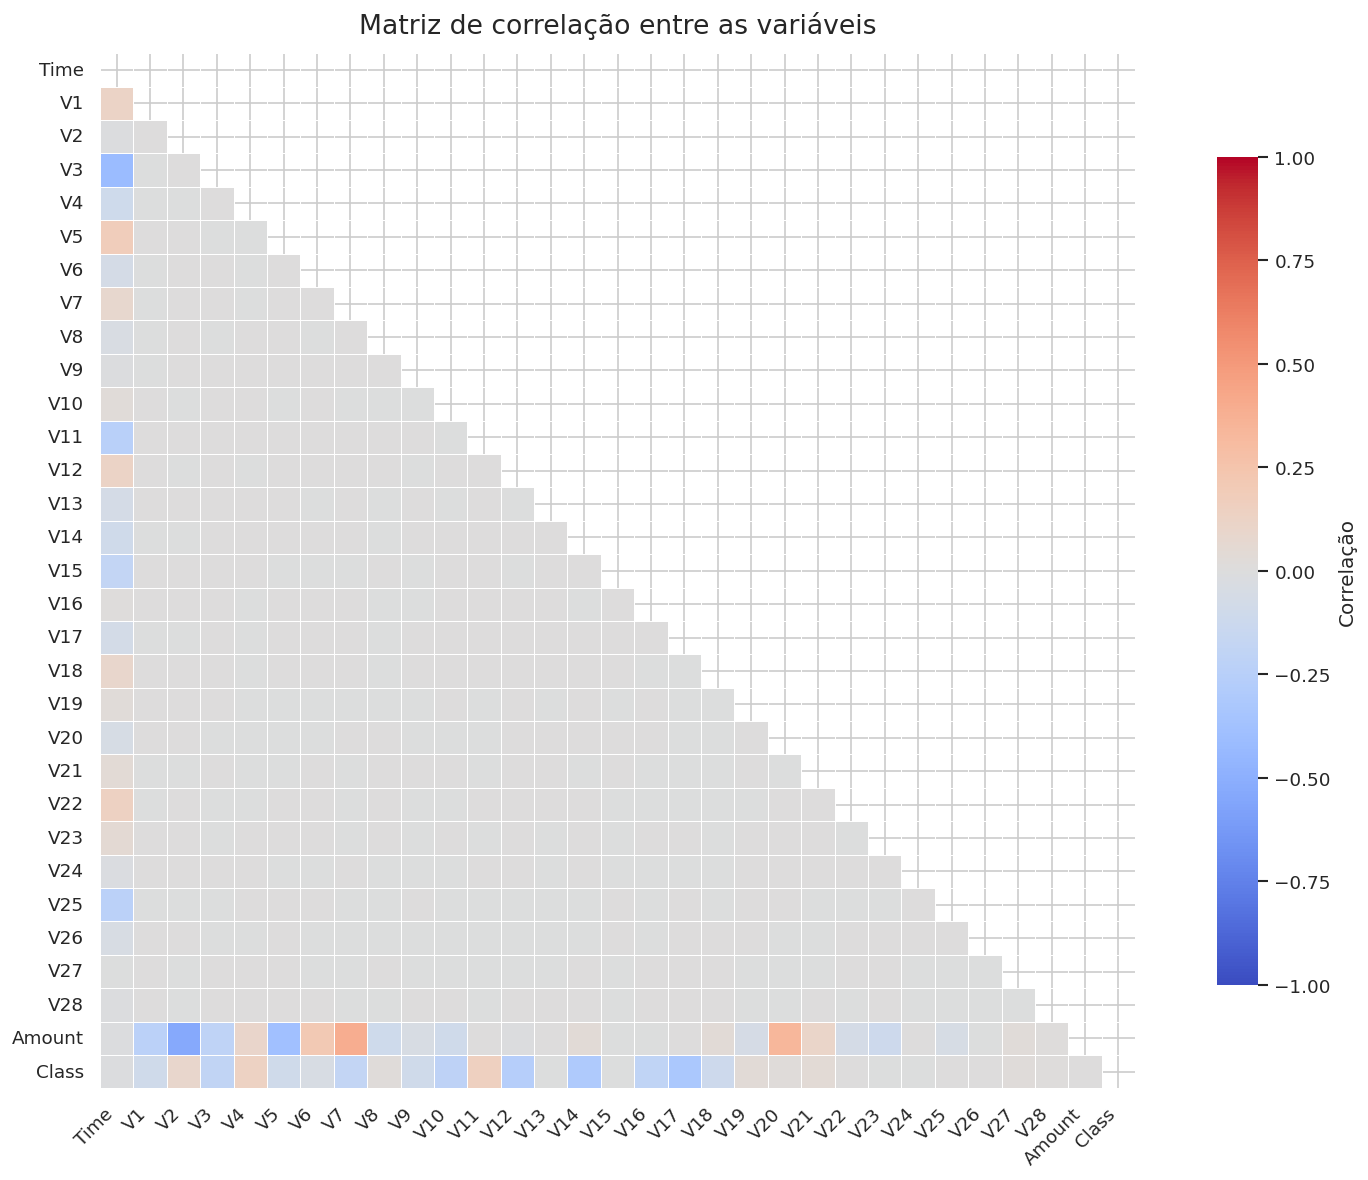

In [41]:
# Matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlação"}
)
plt.title("Matriz de correlação entre as variáveis", fontsize=16, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()


/tmp/ipykernel_2893/3543279505.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


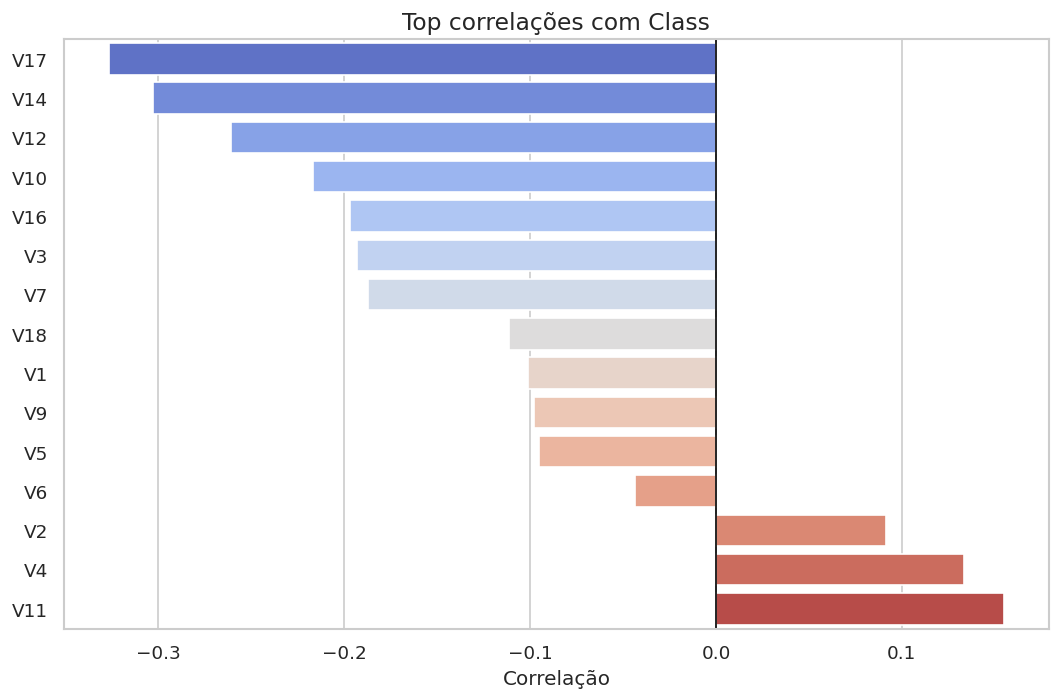

In [51]:
# Correlação das variáveis com a classe
corr_class = df.corr(numeric_only=True)["Class"].sort_values(key=lambda s: s.abs(), ascending=False)

corr_class = corr_class.drop("Class").to_frame("Correlação com Class")
corr_class["Correlação com Class"] = corr_class["Correlação com Class"].round(4)

corr_top = corr_class.head(15).sort_values(by="Correlação com Class")

plt.figure(figsize=(9, 6))
sns.barplot(
    data=corr_top,
    x="Correlação com Class",
    y=corr_top.index,
    palette="coolwarm"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top correlações com Class", fontsize=14)
plt.xlabel("Correlação")
plt.ylabel("")
plt.tight_layout()

/tmp/ipykernel_2893/4221051475.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], palette="Greens_r")
/tmp/ipykernel_2893/4221051475.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], palette="Reds_r")


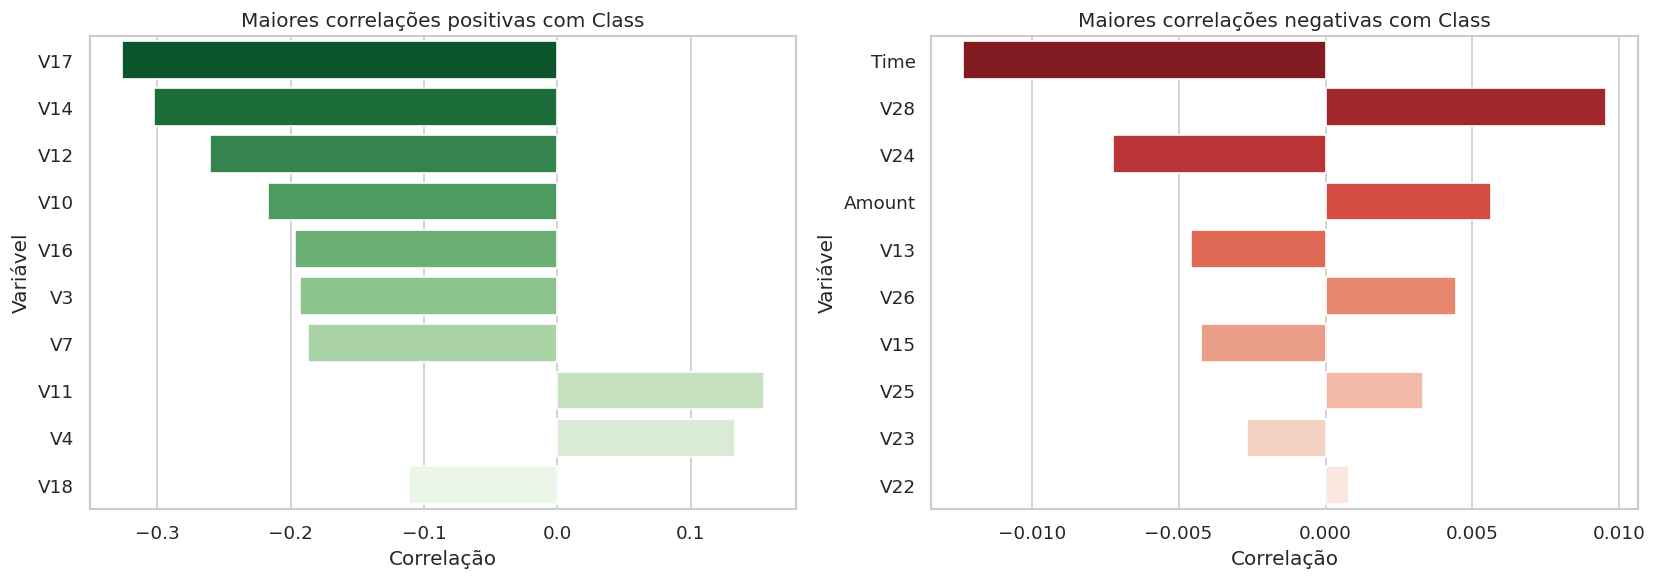

In [52]:
corr_class = df.corr(numeric_only=True)["Class"].sort_values(key=lambda s: s.abs(), ascending=False)
corr_class = corr_class.drop("Class")

top_pos = corr_class.head(10)
top_neg = corr_class.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], palette="Greens_r")
axes[0].set_title("Maiores correlações positivas com Class")
axes[0].set_xlabel("Correlação")
axes[0].set_ylabel("Variável")

sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], palette="Reds_r")
axes[1].set_title("Maiores correlações negativas com Class")
axes[1].set_xlabel("Correlação")
axes[1].set_ylabel("Variável")

plt.tight_layout()
plt.show()

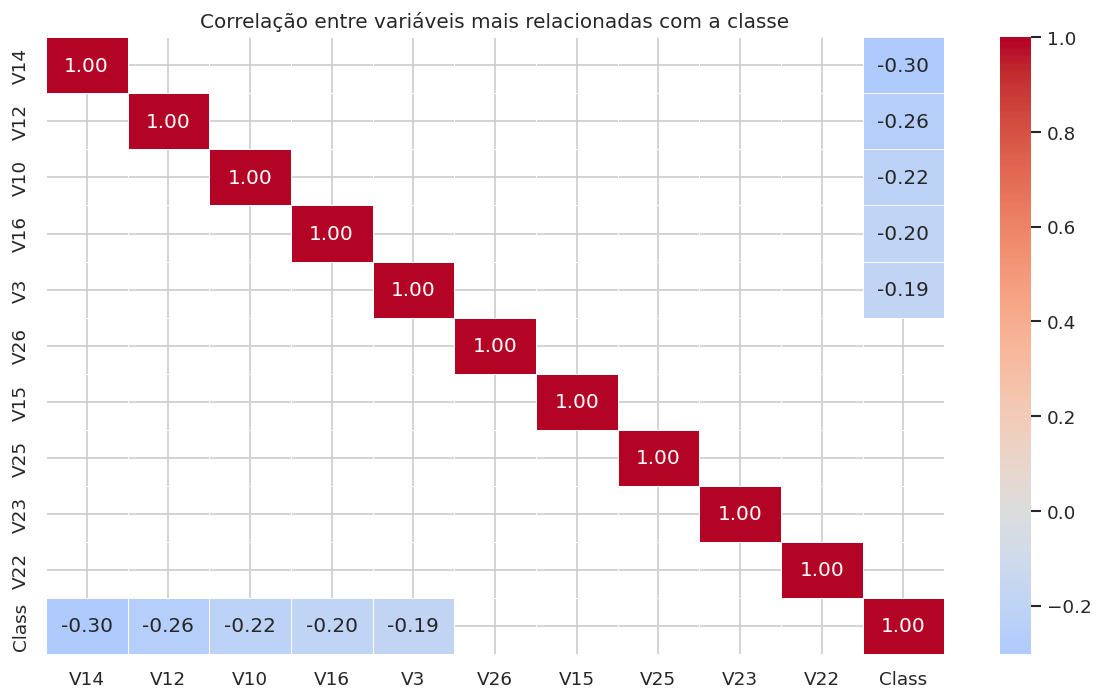

In [59]:
# Seleção das variáveis mais correlacionadas com a classe
corr_sel = df[selected_features].corr()
corr_sel = corr_sel.mask(corr_sel.abs() < 0.05)

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_sel,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlação entre variáveis mais relacionadas com a classe")
plt.tight_layout()
plt.show()

### 1.7 Interpretação da correlação

A análise de correlação mostra que algumas variáveis transformadas por PCA apresentam associação mais forte com a variável-alvo `Class`, tanto de forma positiva quanto negativa. Isso sugere que esses atributos podem contribuir de forma mais relevante para a identificação de fraudes.

No entanto, correlação não implica causalidade, e relações não lineares podem não ser capturadas por essa análise. Assim, a confirmação da relevância dessas variáveis dependerá do desempenho efetivo dos modelos preditivos nas etapas seguintes.

## 2. Preparação dos dados

Nesta etapa, os dados serão preparados para a modelagem. O objetivo é separar as variáveis preditoras da variável-alvo, dividir a base em treino e teste preservando a proporção das classes e padronizar as variáveis `Amount` e `Time`.

In [60]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X:", X.shape)
print("y:", y.shape)

X: (284807, 30)
y: (284807,)


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino X:", X_train.shape)
print("Teste X:", X_test.shape)
print("Treino y:", y_train.shape)
print("Teste y:", y_test.shape)

print("\nDistribuição em y_train:")
print(y_train.value_counts(normalize=True).round(4))

print("\nDistribuição em y_test:")
print(y_test.value_counts(normalize=True).round(4))

Treino X: (227845, 30)
Teste X: (56962, 30)
Treino y: (227845,)
Teste y: (56962,)

Distribuição em y_train:
Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64

Distribuição em y_test:
Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64


### 2.1 Padronização das variáveis

As variáveis `Amount` e `Time` possuem escalas distintas das demais variáveis da base. Para evitar que isso interfira na modelagem, será aplicado `StandardScaler` apenas nessas colunas.

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[["Amount", "Time"]] = scaler.fit_transform(X_train[["Amount", "Time"]])
X_test[["Amount", "Time"]] = scaler.transform(X_test[["Amount", "Time"]])

display(X_train[["Amount", "Time"]].head())

,Amount,Time
265518,-0.322494,1.411588
180305,-0.339764,0.623141
42664,0.346693,-1.130680
198723,-0.327360,0.794699
82325,-0.008281,-0.748102


In [63]:
print("Verificação final:")
print("Valores ausentes em X_train:", X_train.isnull().sum().sum())
print("Valores ausentes em X_test:", X_test.isnull().sum().sum())
print("Valores ausentes em y_train:", y_train.isnull().sum())
print("Valores ausentes em y_test:", y_test.isnull().sum())

Verificação final:
Valores ausentes em X_train: 0
Valores ausentes em X_test: 0
Valores ausentes em y_train: 0
Valores ausentes em y_test: 0


### 2.2 Resultado da preparação

Os dados foram separados em conjuntos de treino e teste com estratificação, preservando a proporção original entre fraudes e não fraudes. As variáveis Amount e Time foram padronizadas para reduzir diferenças de escala e evitar impactos indevidos na modelagem.
Com isso, a base ficou pronta para a etapa de modelagem preditiva.

## 3. Modelagem inicial

Nesta etapa, serão treinados modelos de classificação para identificar transações fraudulentas. Como o problema apresenta forte desbalanceamento entre classes, a avaliação será baseada principalmente em métricas mais adequadas, como **precision**, **recall**, **F1-score** e **ROC-AUC**.

Inicialmente, será criado um baseline simples e, em seguida, serão testados modelos supervisionados de classificação.

In [64]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

### 3.1 Modelo baseline

Como referência inicial, será utilizado um modelo baseline que sempre prevê a classe majoritária. Isso permite verificar se os modelos treinados realmente agregam valor em relação a uma solução ingênua.

In [65]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("=== Baseline ===")
print(classification_report(y_test, y_pred_baseline, digits=4))

=== Baseline ===
              precision    recall  f1-score   support

           0     0.9983    1.0000    0.9991     56864
           1     0.0000    0.0000    0.0000        98

    accuracy                         0.9983     56962
   macro avg     0.4991    0.5000    0.4996     56962
weighted avg     0.9966    0.9983    0.9974     56962



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


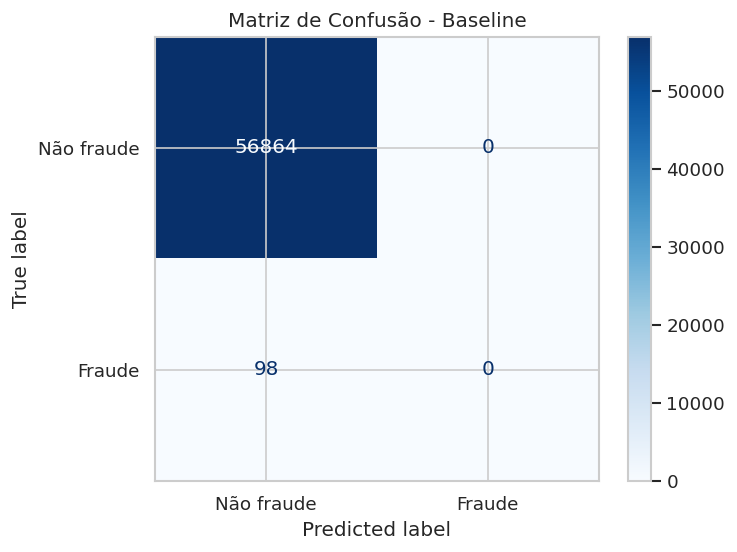

In [66]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=["Não fraude", "Fraude"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - Baseline")
plt.show()

### 3.2 Regressão Logística

A Regressão Logística será utilizada como primeiro modelo supervisionado. Trata-se de um algoritmo clássico de classificação binária, com boa interpretabilidade e frequentemente usado como benchmark em problemas estruturados.

In [67]:
log_reg = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

print("=== Regressão Logística ===")
print(classification_report(y_test, y_pred_log, digits=4))

print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_log), 4))

=== Regressão Logística ===
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962

ROC-AUC: 0.9722


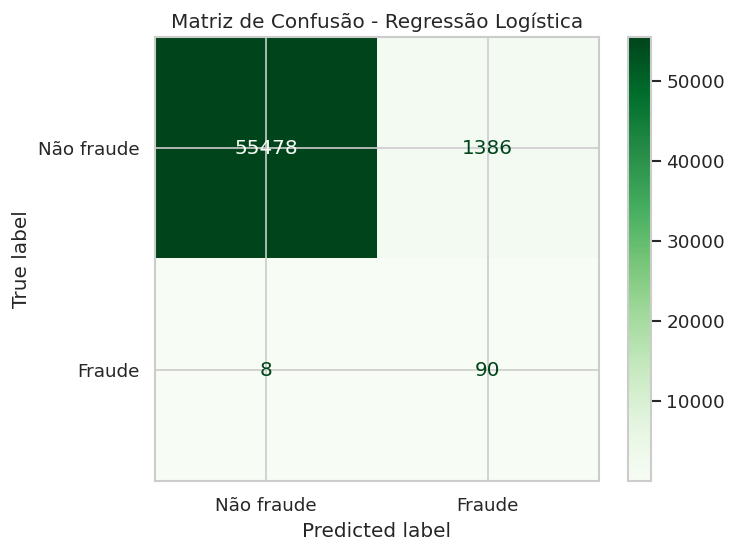

In [68]:
cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Não fraude", "Fraude"])
disp.plot(cmap="Greens", values_format="d")
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

### 3.3 Interpretação inicial dos resultados

O baseline serve como referência mínima de desempenho. Em bases altamente desbalanceadas, esse tipo de modelo pode apresentar boa acurácia ao prever apenas a classe majoritária, mas tende a falhar completamente na identificação das fraudes.

Já a Regressão Logística representa um avanço importante, pois permite efetivamente separar classes com base nas variáveis disponíveis. O uso de `class_weight="balanced"` ajuda a compensar o desbalanceamento da base durante o treinamento.

### 3.4 Árvore de Decisão

A Árvore de Decisão é um modelo supervisionado capaz de capturar relações não lineares entre as variáveis. Além de ser relativamente interpretável, ela permite observar como regras de decisão podem separar transações fraudulentas das legítimas.

In [69]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=5
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

print("=== Árvore de Decisão ===")
print(classification_report(y_test, y_pred_tree, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_tree), 4))

=== Árvore de Decisão ===
              precision    recall  f1-score   support

           0     0.9998    0.9696    0.9845     56864
           1     0.0474    0.8776    0.0899        98

    accuracy                         0.9694     56962
   macro avg     0.5236    0.9236    0.5372     56962
weighted avg     0.9981    0.9694    0.9829     56962

ROC-AUC: 0.9166


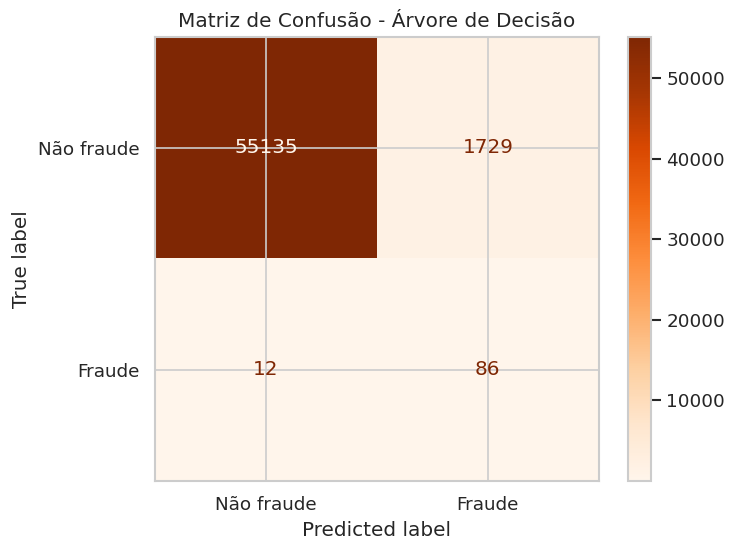

In [70]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Não fraude", "Fraude"])
disp.plot(cmap="Oranges", values_format="d")
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

### 3.5 Random Forest

O Random Forest é um modelo de ensemble baseado em múltiplas árvores de decisão. Em problemas de fraude, ele costuma apresentar desempenho superior ao de uma árvore isolada, pois reduz a variância e melhora a capacidade de generalização.

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))

=== Random Forest ===
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9605    0.7449    0.8391        98

    accuracy                         0.9995     56962
   macro avg     0.9800    0.8724    0.9194     56962
weighted avg     0.9995    0.9995    0.9995     56962

ROC-AUC: 0.9529


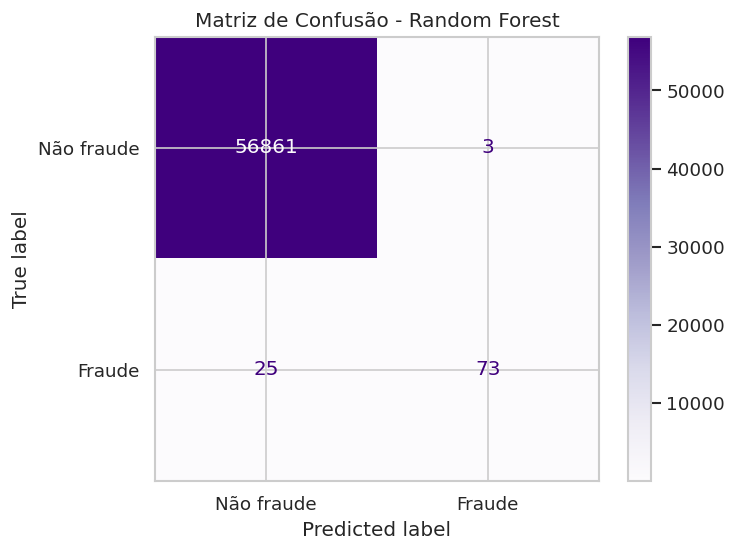

In [72]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Não fraude", "Fraude"])
disp.plot(cmap="Purples", values_format="d")
plt.title("Matriz de Confusão - Random Forest")
plt.show()

In [76]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    "Modelo": ["Baseline", "Regressão Logística", "Árvore de Decisão", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline, zero_division=0),
        precision_score(y_test, y_pred_log, zero_division=0),
        precision_score(y_test, y_pred_tree, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline, zero_division=0),
        recall_score(y_test, y_pred_log, zero_division=0),
        recall_score(y_test, y_pred_tree, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_baseline, zero_division=0),
        f1_score(y_test, y_pred_log, zero_division=0),
        f1_score(y_test, y_pred_tree, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ],
    "ROC-AUC": [
        np.nan,
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_tree),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

display(results.round(4).sort_values(by="Recall", ascending=False))

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Regressão Logística,0.9755,0.0610,0.9184,0.1144,0.9722
2,Árvore de Decisão,0.9694,0.0474,0.8776,0.0899,0.9166
3,Random Forest,0.9995,0.9605,0.7449,0.8391,0.9529
0,Baseline,0.9983,0.0000,0.0000,0.0000,NaN


### 3.6 Comparação inicial dos modelos

A comparação entre os modelos permite avaliar quais abordagens são mais eficazes para identificar fraudes em um cenário de forte desbalanceamento. Mais do que acurácia, o foco deve estar na capacidade do modelo de identificar corretamente a classe minoritária.

Nesta etapa, a análise será orientada principalmente pelas métricas de **recall**, **precision**, **F1-score** e **ROC-AUC**, com atenção especial ao desempenho da classe fraude.

## 4. Ajuste de hiperparâmetros

Após a comparação inicial dos modelos, será realizado o ajuste de hiperparâmetros no modelo com melhor potencial. Como o problema envolve detecção de fraudes em uma base altamente desbalanceada, o foco da otimização será a métrica **recall**, priorizando a capacidade de identificar a classe fraudulenta.

In [77]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_grid = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_grid = {
    "n_estimators": [50],
    "max_depth": [5],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring="recall",
    cv=2,
    n_jobs=-1,
    verbose=1
)

In [78]:
grid_search.fit(X_train, y_train)

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor recall médio na validação cruzada:", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Melhores parâmetros: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Melhor recall médio na validação cruzada: 0.8426


In [80]:
y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Ajustado ===")
print(classification_report(y_test, y_pred_best_rf, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_best_rf), 4))

=== Random Forest Ajustado ===
              precision    recall  f1-score   support

           0     0.9998    0.9963    0.9980     56864
           1     0.2910    0.8878    0.4383        98

    accuracy                         0.9961     56962
   macro avg     0.6454    0.9420    0.7182     56962
weighted avg     0.9986    0.9961    0.9971     56962

ROC-AUC: 0.976


## 5. Conclusão

Este projeto apresentou um fluxo completo de Machine Learning aplicado à detecção de fraudes em transações com cartão de crédito. Inicialmente, foi realizada a análise exploratória dos dados, que evidenciou o forte desbalanceamento entre as classes e a necessidade de utilizar métricas mais adequadas do que a acurácia.

Na etapa de modelagem, foram comparados diferentes algoritmos de classificação, incluindo baseline, Regressão Logística, Árvore de Decisão e Random Forest. Os resultados mostraram que modelos supervisionados conseguem superar amplamente o baseline na identificação de fraudes, especialmente quando são utilizados mecanismos de balanceamento, como `class_weight`.

O melhor resultado foi obtido com o Random Forest ajustado, que apresentou recall de 0.8878 para a classe fraude e ROC-AUC de 0.976, indicando boa capacidade de identificar transações fraudulentas sem perder completamente a separação entre as classes.

De forma geral, os resultados indicam que a escolha do modelo deve considerar não apenas a acurácia global, mas principalmente a capacidade de detectar fraudes com equilíbrio entre **recall**, **precision** e **F1-score**.

Como trabalhos futuros, o projeto pode ser expandido com técnicas adicionais de tratamento de desbalanceamento, como SMOTE, ajuste de limiar de decisão, validação cruzada mais robusta e comparação com algoritmos mais avançados, como XGBoost.